## Дисклеймер!!!!!

Поскольку я терпеть ненавижу отвратно структурированный код, я большую часть инжиринга признаков вынес в отдельный файл. Направление действий будет видно как и указано в задании, но сразу для всего. Я не писал всё одним батчем, тут положена куча коммитов, просто для сохранения ясности я решил не сваливать всё в одну нечитабельную кучу. 

## Грузим данные

In [1]:
from data_preparation import OzonDataFormer
from datetime import date

In [2]:
former = OzonDataFormer()

In [3]:
former.fit_text_vectorizer(feature_end_date=date(2024, 5, 31))

In [4]:
train_df = former.construct_dataset(
    feature_end_date=date(2024, 5, 31),
    target_start_date=date(2024, 6, 1),
    target_end_date=date(2024, 6, 30),
)

In [5]:
val_df = former.construct_dataset(
    feature_end_date=date(2024, 6, 30),
    target_start_date=date(2024, 7, 1),
    target_end_date=date(2024, 7, 31),
)

In [6]:
X_train = train_df.drop(columns=['user_id', 'target'])
y_train = train_df['target']

In [8]:
X_val = val_df.drop(columns=['user_id', 'target'])
y_val = val_df['target']

In [9]:
from utils2 import AutoFeatureStandardizer

In [10]:
standardizer = AutoFeatureStandardizer()

In [11]:
X_train_s = standardizer.fit_transform(X_train)

/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at on

In [12]:
X_val_s = standardizer.transform(X_val)

/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at on

## Проверка адекватности разделения на тренировку и валидацию

In [13]:
cat_features = list(X_train_s.select_dtypes('category').columns) + list(X_train_s.select_dtypes('object').columns)

In [14]:
# embedding_features = ['search_emb']

In [15]:
from catboost.utils import get_gpu_device_count

if get_gpu_device_count() > 0:
    task_type = 'GPU'
else:
    task_type = 'CPU'

params = {
    'iterations': 100,
    'depth': 7,
    'learning_rate': 0.05,
    'random_state': 1,
    'eval_metric': 'AUC',
    'loss_function': 'Logloss',
    'auto_class_weights': 'Balanced',
    'task_type': task_type,
    'cat_features': cat_features,
    # 'embedding_features': embedding_features
}

# search_tfidfsvd

Error 35 (CUDA driver version is insufficient for CUDA runtime version) ignored while obtaining device count


In [16]:
# from validation_check import get_train_val_difference

# diff_score, _, _ = get_train_val_difference(X_train, y_train, X_val, y_val, params)

In [17]:
# diff_score

Ну выглядит вроде адекватно учитывая что в данных очевидно есть временная зависимость

## Обучение модели

In [18]:
from catboost import CatBoostClassifier, Pool

In [19]:
train_pool = Pool(X_train_s, label=y_train, cat_features=cat_features)

val_pool = Pool(X_val_s, label=y_val, cat_features=cat_features)

In [20]:
params['iterations'] = 5000

model = CatBoostClassifier(**params)

In [21]:
try:
    model.load_model('models/weird_shiet.bin')
except Exception:
    model.fit(
        train_pool,
        eval_set=val_pool,
        use_best_model=True,
        verbose=10,
        early_stopping_rounds=50,
    )

In [22]:
model.save_model("models/weird_shiet.bin")

In [23]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

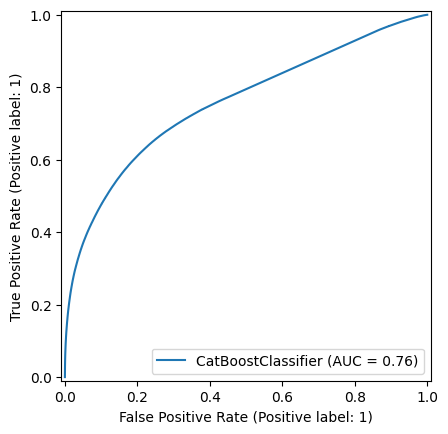

In [24]:
RocCurveDisplay.from_estimator(model, X_val_s, y_val)

## Интерпретация модели

In [25]:
from utils2 import AutoFeatureStandardizer, BinaryClassifierInterpreter
from cluster_compare import NotebookBinaryClusterInterpreter

In [26]:
import panel as pn
pn.extension()

In [41]:
tool = NotebookBinaryClusterInterpreter(
    X=X_train_s.loc[::30],
    y=y_train.loc[::30],
)
tool.show()

/home/i3alumba/Projects/AI/aim_ml/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


BokehModel(combine_events=True, render_bundle={'docs_json': {'e1aa1bb9-79cc-4db3-a6bd-4a82e75a8658': {'version…

А выглядит интересно, чётко видны 2 кластер, надо посмотреть чё там такое.

## UPD
Я добавил соотношение меток классов к кластерам, получается интересная картина. Мб имеет смысл использовать результаты кластеризации как признаки для моделb

In [35]:
interpreter = BinaryClassifierInterpreter(
    train=(X_train_s[::30], y_train[::30]),
    val=(X_val_s[::10], y_val[::10]),
    model=model
)

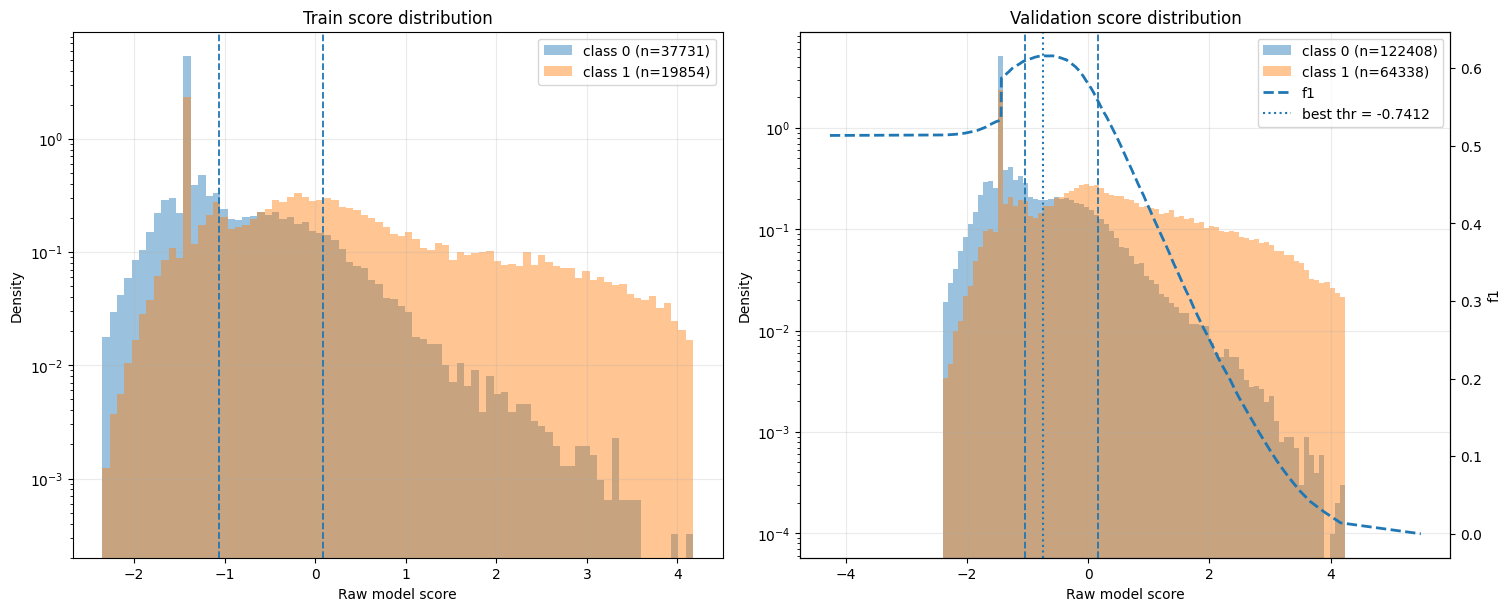

In [36]:
interpreter.plot_score_histograms_with_val_metric(val_metric_name="f1", use_log_density_y=True);

In [31]:
interpreter.plot_float_feature_histograms()

In [32]:
interpreter.plot_score_feature_contours()

In [33]:
interpreter.plot_shap_beeswarm(sample_frac=0.1)

Found a NULL input array in _cext_dense_tree_update_weights!


ExplainerError: Currently TreeExplainer can only handle models with categorical splits when feature_perturbation="tree_path_dependent" and no background data is passed. Please try again using shap.TreeExplainer(model, feature_perturbation="tree_path_dependent").

In [ ]:
test_df = former.construct_dataset(
    feature_end_date=date(2024, 7, 31),
    users_df=former.test_users_submission,
)

In [ ]:
predict = model.predict(test_df.drop(columns='user_id'), prediction_type='RawFormulaVal')

In [ ]:
from scipy.special import expit

In [ ]:
probs = expit(predict)

In [ ]:
import pandas as pd
import polars as pl

In [ ]:
test_df['predict'] = probs
test_df[['user_id', 'predict']].to_csv('overfitted_ahh.csv', index=False)